# Import data
Hallo alle

store nbr = 44
item nbr = 1047679

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/timeseries.csv", parse_dates=["date"])
df = df.set_index("date").sort_index()

df.head()


,unit_sales
date,
2013-01-02,582.0
2013-01-03,310.0
2013-01-04,338.0
2013-01-05,654.0
2013-01-06,979.0


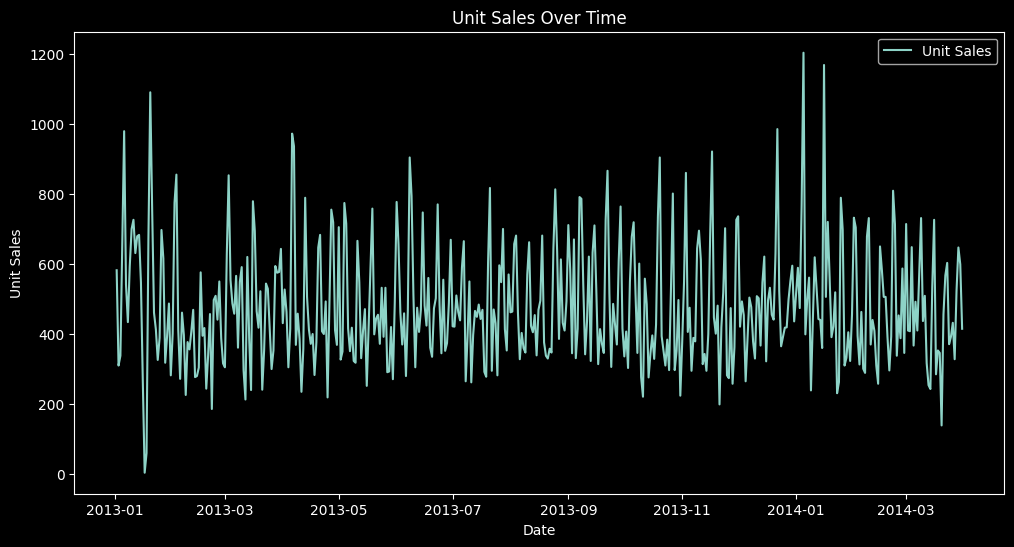

In [3]:
# Visualize the data
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['unit_sales'], label='Unit Sales')
plt.title('Unit Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Unit Sales')
plt.legend()
plt.show()

# Exploratory Data Analysis (EDA)

## Outlier Detection

In [4]:
# Calculate z-scores to identify outliers
from scipy import stats
import numpy as np
z_scores = np.abs(stats.zscore(df['unit_sales'])) ## np.abs() takes the absolute value
                                                  ## stats.zscore() calculates standardized values
outliers = df[z_scores > 5]
outliers


,unit_sales
date,


### There are no extreme outliers beyond 5 standard deviations.

## Missing Values

In [5]:
# Check for missing values
missing_values = df.isnull().sum()
missing_values

unit_sales    0
dtype: int64

In [6]:
pd.date_range(start=df.index.min(), end=df.index.max())

DatetimeIndex(['2013-01-02', '2013-01-03', '2013-01-04', '2013-01-05',
               '2013-01-06', '2013-01-07', '2013-01-08', '2013-01-09',
               '2013-01-10', '2013-01-11',
               ...
               '2014-03-22', '2014-03-23', '2014-03-24', '2014-03-25',
               '2014-03-26', '2014-03-27', '2014-03-28', '2014-03-29',
               '2014-03-30', '2014-03-31'],
              dtype='datetime64[us]', length=454, freq='D')

In [7]:
df.index

DatetimeIndex(['2013-01-02', '2013-01-03', '2013-01-04', '2013-01-05',
               '2013-01-06', '2013-01-07', '2013-01-08', '2013-01-09',
               '2013-01-10', '2013-01-11',
               ...
               '2014-03-22', '2014-03-23', '2014-03-24', '2014-03-25',
               '2014-03-26', '2014-03-27', '2014-03-28', '2014-03-29',
               '2014-03-30', '2014-03-31'],
              dtype='datetime64[us]', name='date', length=452, freq=None)

In [8]:
# Check if all days are present
date_range = pd.date_range(start=df.index.min(), end=df.index.max())
missing_dates = date_range.difference(df.index)
missing_dates

DatetimeIndex(['2013-12-25', '2014-01-01'], dtype='datetime64[us]', freq=None)

In [9]:
# Solve missing dates by forward filling
df = df.reindex(date_range)
df

,unit_sales
2013-01-02,582.0
2013-01-03,310.0
2013-01-04,338.0
2013-01-05,654.0
2013-01-06,979.0
...,...
2014-03-27,328.0
2014-03-28,523.0
2014-03-29,647.0
2014-03-30,599.0


In [10]:
df[df['unit_sales'].isna()]


,unit_sales
2013-12-25,NaN
2014-01-01,NaN


In [11]:
df['unit_sales'] = df['unit_sales'].fillna(0)


In [12]:
df.loc[['2013-12-25', '2014-01-01']]


,unit_sales
2013-12-25,0.0
2014-01-01,0.0


### Missing calendar dates correspond to full-day store closures; therefore I reindex to a complete daily range and fill missing sales with 0 instead of forward-filling.

## Summary Statistics

In [13]:

summary_stats = df['unit_sales'].describe()
summary_stats

count     454.000000
mean      477.975771
std       173.408453
min         0.000000
25%       356.500000
50%       443.500000
75%       576.750000
max      1203.000000
Name: unit_sales, dtype: float64

### High sales days deviate more strongly from the typical day than low sales days - right skew

## Seasonal Decomposition

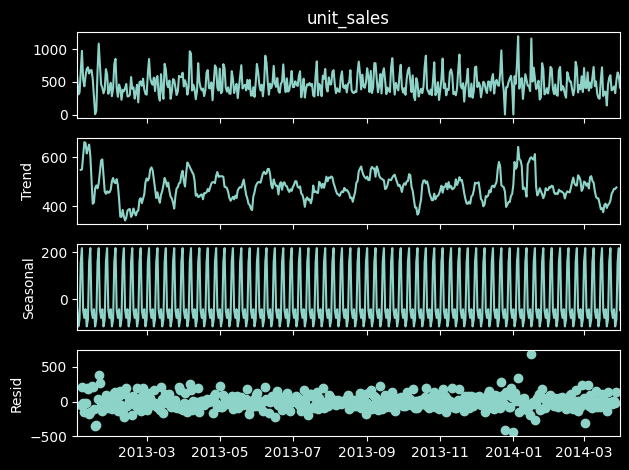

In [14]:

from statsmodels.tsa.seasonal import seasonal_decompose

# Set frequenc to daily
df = df.asfreq('D')  # This is done for seasonal decomposition to infere seasonal patterns
# Perform seasonal decomposition
decomposition = seasonal_decompose(df['unit_sales'], model='additive')
decomposition.plot()
plt.show()

### This confirms the EDA conclusions mathematically:
* Seasonality dominates*
* Trend is mild*
* Holidays create irregular deviations*
* Very strong analytical alignment.

## Stationarity Test

In [15]:

from statsmodels.tsa.stattools import adfuller
# Perform Augmented Dickey-Fuller test
adf_result = adfuller(df['unit_sales'])
adf_result_dict = {
    'ADF Statistic': adf_result[0],
    'p-value': adf_result[1],
    'Critical Values': adf_result[4]
}
adf_result_dict



{'ADF Statistic': np.float64(-5.343772240147954),
 'p-value': np.float64(4.441049433078282e-06),
 'Critical Values': {'1%': np.float64(-3.4454725477848998),
  '5%': np.float64(-2.8682072297316794),
  '10%': np.float64(-2.570321396485665)}}

The Augmented Dickey–Fuller test strongly rejects the null hypothesis of a unit root (ADF = -5.34, p ≈ 4.4e-06). This indicates the series is stationary in the unit-root sense, meaning it does not behave like a random walk or show uncontrolled stochastic drift. However, the series still contains strong deterministic seasonality (weekly pattern), so while differencing may not be strictly necessary for stationarity, seasonal structure still needs to be accounted for in further analysis/modeling.

## Autocorrelation Analysis

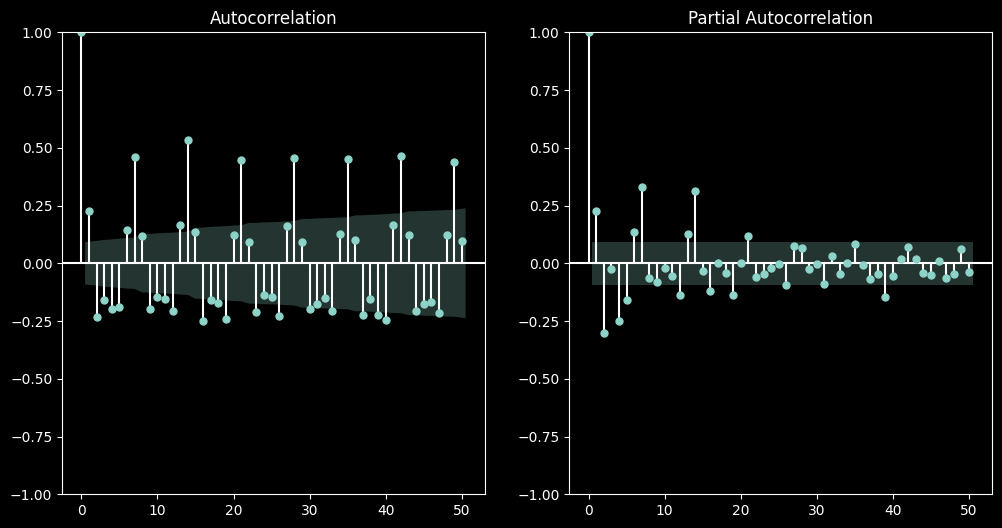

In [16]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
# Plot ACF and PACF
plt.figure(figsize=(12, 6))
plt.subplot(121)
plot_acf(df['unit_sales'], ax=plt.gca(), lags=50)
plt.subplot(122)
plot_pacf(df['unit_sales'], ax=plt.gca(), lags=50)
plt.show()



### The ACF plot shows strong autocorrelation at lag 7 and its multiples, confirming a dominant weekly seasonal pattern. The PACF indicates significant short-term dependence, especially at lag 1, suggesting that recent sales strongly influence current sales. Overall, the series exhibits clear temporal structure consistent with retail demand cycles.

# For Students: Further EDA and Analysis
Ideas:
    - Do holidays impact sales?
    - Does the day of the week the impact sales?
    - Does the oil price impact sales?
    - Get creative and explore the data further! Even if the results show that there is no impact, that is still a useful finding!! We would like mostly to see the thought process no need on statistical perfection (:

### Does Day of Week Impact Sales?

In [17]:
# Create day of week column
df['day_of_week'] = df.index.day_name()

# Group by day of week
avg_sales_dow = df.groupby('day_of_week')['unit_sales'].mean()

# Sort by weekday order
weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
avg_sales_dow = avg_sales_dow.reindex(weekday_order)

avg_sales_dow


day_of_week
Monday       429.969231
Tuesday      397.718750
Wednesday    437.092308
Thursday     359.661538
Friday       389.230769
Saturday     636.830769
Sunday       694.092308
Name: unit_sales, dtype: float64

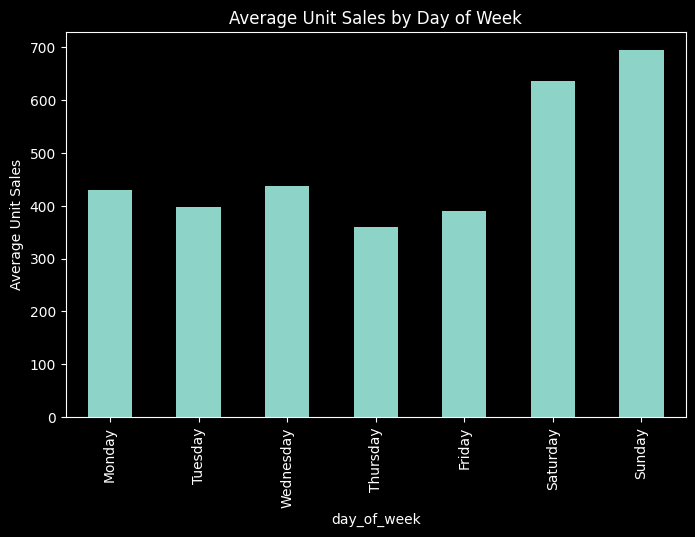

In [18]:
plt.figure(figsize=(8,5))
avg_sales_dow.plot(kind='bar')
plt.title("Average Unit Sales by Day of Week")
plt.ylabel("Average Unit Sales")
plt.show()


This strongly suggests:
* There is weekly seasonality*
* Sales behavior is driven by customer shopping patterns*
* Weekend demand is structurally higher

This means:
* Any forecasting model MUST capture weekly seasonality*
* A simple trend-only model would miss this

<Figure size 1000x600 with 0 Axes>

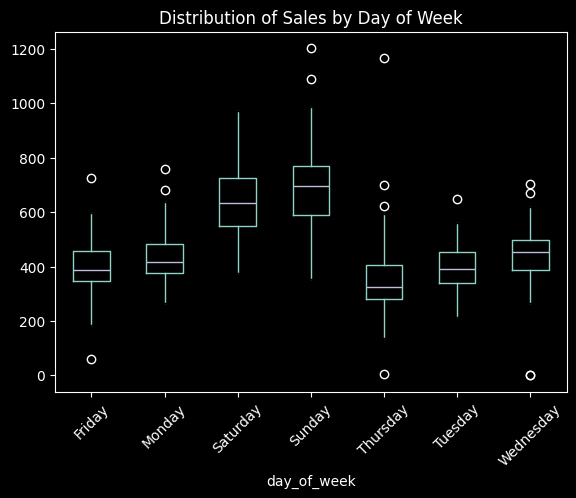

In [19]:
# Boxplot by day of week
plt.figure(figsize=(10,6))
df.boxplot(column='unit_sales', by='day_of_week', grid=False)
plt.xticks(rotation=45)
plt.title("Distribution of Sales by Day of Week")
plt.suptitle("")
plt.show()


### Sales show strong weekly seasonality, with weekends consistently outperforming weekdays. The effect is persistent across the entire time period and not driven by a few extreme values.

In [20]:
holidays = pd.read_csv("../data/holidays.csv")
holidays.head()


,date,locale,locale_name,description
0,2012-03-02,Local,Manta,Fundacion de Manta
1,2012-04-01,Regional,Cotopaxi,Provincializacion de Cotopaxi
2,2012-04-12,Local,Cuenca,Fundacion de Cuenca
3,2012-04-14,Local,Libertad,Cantonizacion de Libertad
4,2012-04-21,Local,Riobamba,Cantonizacion de Riobamba


In [21]:
holidays['date'] = pd.to_datetime(holidays['date'])


In [22]:
# Create holiday flag
df['is_holiday'] = df.index.isin(holidays['date'])

# Check how many holiday days
df['is_holiday'].sum()


np.int64(49)

In [23]:
df.groupby('is_holiday')['unit_sales'].mean()


is_holiday
False    476.390123
True     491.081633
Name: unit_sales, dtype: float64

### Is the increase caused by holidays?
OR
Is it just because holidays often happen on Saturdays/Sundays?

## Compare Holidays vs Non-Holidays Within Each Day of Week

In [24]:
pd.pivot_table(
    df,
    values='unit_sales',
    index='day_of_week',
    columns='is_holiday',
    aggfunc='mean'
)


is_holiday,False,True
day_of_week,,
Friday,390.180328,374.750000
Monday,424.210526,471.000000
Saturday,639.535714,620.000000
Sunday,699.678571,659.333333
Thursday,361.416667,338.600000
Tuesday,393.105263,435.285714
Wednesday,446.017241,363.142857


### Holidays do not uniformly increase sales.
* On weekdays, holidays increase sales.
* On weekends, holidays actually reduce sales slightly.

This suggests:
* Weekday holidays behave like “mini-weekends” → people shop more.
* Weekend holidays may reduce regular weekend shopping (maybe closures, travel, family events).

#### The impact of holidays depends on the day of the week. Holidays boost weekday sales but do not enhance — and may slightly reduce — weekend sales.

In [25]:
df.head()
df.index

DatetimeIndex(['2013-01-02', '2013-01-03', '2013-01-04', '2013-01-05',
               '2013-01-06', '2013-01-07', '2013-01-08', '2013-01-09',
               '2013-01-10', '2013-01-11',
               ...
               '2014-03-22', '2014-03-23', '2014-03-24', '2014-03-25',
               '2014-03-26', '2014-03-27', '2014-03-28', '2014-03-29',
               '2014-03-30', '2014-03-31'],
              dtype='datetime64[us]', length=454, freq='D')

In [26]:
# --- Normalize df so it is safe to run the instructor merge cell ---
# Goal: df must have a DatetimeIndex named 'date' and NO 'date' column.

import pandas as pd

# If we already have a 'date' column, make it the index
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'])
    df = df.set_index('date')

# If index is not datetime, convert if possible
if not pd.api.types.is_datetime64_any_dtype(df.index):
    df.index = pd.to_datetime(df.index, errors='coerce')

# Name the index properly
df.index.name = 'date'

# Ensure sorted and unique index (prevents many downstream issues)
df = df[~df.index.duplicated(keep='first')].sort_index()

# Important: remove a duplicate 'date' column if it exists
df = df.loc[:, ~df.columns.duplicated()]

In [27]:
# If a 'date' column already exists while date is also the index, drop the column first
if df.index.name == 'date' and 'date' in df.columns:
    df = df.drop(columns=['date'])

# Now reset index safely
if df.index.name == 'date':
    df = df.reset_index()

# Ensure datetime types
df['date'] = pd.to_datetime(df['date'])
holidays['date'] = pd.to_datetime(holidays['date'])

# Merge locale
df = df.merge(
    holidays[['date', 'locale']],
    how='left',
    on='date'
)

# Back to time index
df = df.set_index('date')

df[['unit_sales', 'locale']].head(10)


,unit_sales,locale
date,,
2013-01-02,582.0,NaN
2013-01-03,310.0,NaN
2013-01-04,338.0,NaN
2013-01-05,654.0,National
2013-01-06,979.0,NaN
2013-01-07,541.0,NaN
2013-01-08,434.0,NaN
2013-01-09,593.0,NaN
2013-01-10,700.0,NaN


In [28]:
print(holidays.columns)
holidays.head()

Index(['date', 'locale', 'locale_name', 'description'], dtype='str')


,date,locale,locale_name,description
0,2012-03-02,Local,Manta,Fundacion de Manta
1,2012-04-01,Regional,Cotopaxi,Provincializacion de Cotopaxi
2,2012-04-12,Local,Cuenca,Fundacion de Cuenca
3,2012-04-14,Local,Libertad,Cantonizacion de Libertad
4,2012-04-21,Local,Riobamba,Cantonizacion de Riobamba


In [29]:
# Replace NaN with 'Non-holiday'
df['holiday_type'] = df['locale'].fillna('Non-holiday')

# Average unit sales by holiday type
df.groupby('holiday_type')['unit_sales'].mean().sort_values(ascending=False)


holiday_type
National       509.875000
Local          503.807692
Non-holiday    476.390123
Regional       365.000000
Name: unit_sales, dtype: float64

In [30]:
# Add weekday
df['day_of_week'] = df.index.day_name()

# Keep only weekdays (Mon-Fri)
weekdays = ['Monday','Tuesday','Wednesday','Thursday','Friday']
df_weekdays = df[df['day_of_week'].isin(weekdays)]

df_weekdays.groupby('holiday_type')['unit_sales'].mean().sort_values(ascending=False)


holiday_type
Local          409.666667
National       409.600000
Non-holiday    402.532423
Regional       365.000000
Name: unit_sales, dtype: float64

In [31]:
df.loc[(df.index.month == 1) & (df.index.day == 1)]

,unit_sales,day_of_week,is_holiday,locale,holiday_type
date,,,,,
2014-01-01,0.0,Wednesday,True,National,National


In [32]:
df.loc[(df.index.month == 12) & (df.index.day == 24)]


,unit_sales,day_of_week,is_holiday,locale,holiday_type
date,,,,,
2013-12-24,365.0,Tuesday,True,National,National


In [33]:
((df.index.month == 1) & (df.index.day == 1)).sum(), ((df.index.month == 12) & (df.index.day == 24)).sum()


(np.int64(1), np.int64(1))

In [34]:
df.loc[(df.index.month == 1) & (df.index.day == 1), 'unit_sales'].describe()


count    1.0
mean     0.0
std      NaN
min      0.0
25%      0.0
50%      0.0
75%      0.0
max      0.0
Name: unit_sales, dtype: float64

In [35]:
df['unit_sales'].describe()


count     459.000000
mean      478.723312
std       174.336195
min         0.000000
25%       354.500000
50%       444.000000
75%       576.500000
max      1203.000000
Name: unit_sales, dtype: float64

In [36]:
oil = pd.read_csv("../data/oil.csv", parse_dates=["date"])
oil = oil.sort_values("date")

oil.head()


,date,dcoilwtico
0,2013-01-01,NaN
1,2013-01-02,93.14
2,2013-01-03,92.97
3,2013-01-04,93.12
4,2013-01-07,93.20


In [37]:
# Ensure 'date' is the index (works even if you re-run)
if 'date' in oil.columns:
    oil['date'] = pd.to_datetime(oil['date'])
    oil = oil.set_index('date')

oil = oil.sort_index()

# Reindex to daily frequency
oil = oil.asfreq('D')

# Fill missing oil prices
oil['dcoilwtico'] = oil['dcoilwtico'].ffill()

# Optional: fill any leading NaN (e.g., first day)
oil['dcoilwtico'] = oil['dcoilwtico'].bfill()

oil.head(10)

,dcoilwtico
date,
2013-01-01,93.14
2013-01-02,93.14
2013-01-03,92.97
2013-01-04,93.12
2013-01-05,93.12
2013-01-06,93.12
2013-01-07,93.20
2013-01-08,93.21
2013-01-09,93.08


In [38]:
# Merge oil price into sales dataframe
df = df.merge(
    oil[['dcoilwtico']],
    how='left',
    left_index=True,
    right_index=True
)

df[['unit_sales', 'dcoilwtico']].head()


,unit_sales,dcoilwtico
date,,
2013-01-02,582.0,93.14
2013-01-03,310.0,92.97
2013-01-04,338.0,93.12
2013-01-05,654.0,93.12
2013-01-06,979.0,93.12


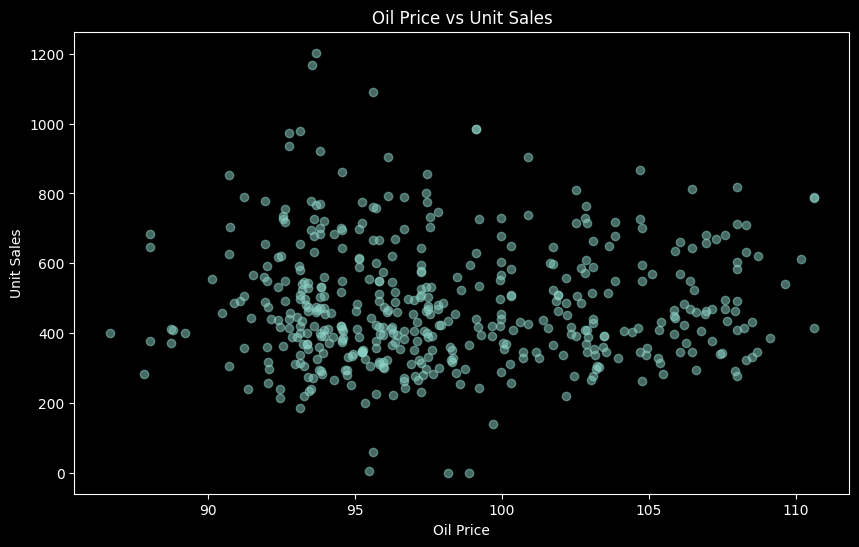

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.scatter(df['dcoilwtico'], df['unit_sales'], alpha=0.5)
plt.xlabel("Oil Price")
plt.ylabel("Unit Sales")
plt.title("Oil Price vs Unit Sales")
plt.show()


In [40]:
df[['unit_sales', 'dcoilwtico']].corr()


,unit_sales,dcoilwtico
unit_sales,1.000000,0.006433
dcoilwtico,0.006433,1.000000


In [41]:
# Create 7-day lag of oil price
df['oil_lag_7'] = df['dcoilwtico'].shift(7)

df[['unit_sales', 'oil_lag_7']].corr()


,unit_sales,oil_lag_7
unit_sales,1.000000,0.007368
oil_lag_7,0.007368,1.000000


In [42]:
weekly = df[['unit_sales', 'dcoilwtico']].resample('W').mean()

weekly.corr()


,unit_sales,dcoilwtico
unit_sales,1.00000,-0.00102
dcoilwtico,-0.00102,1.00000


There is no meaningful linear relationship between oil prices and unit sales in this dataset.
When oil goes up people do not spend less.

Monthly seasonality

In [43]:
df['month'] = df.index.month
df['month_name'] = df.index.month_name()

df[['unit_sales', 'month_name']].head()


,unit_sales,month_name
date,,
2013-01-02,582.0,January
2013-01-03,310.0,January
2013-01-04,338.0,January
2013-01-05,654.0,January
2013-01-06,979.0,January


In [44]:
monthly_avg = df.groupby('month_name')['unit_sales'].mean()

# Sort months properly (not alphabetical)
month_order = [
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
]

monthly_avg = monthly_avg.reindex(month_order)

monthly_avg


month_name
January      512.803279
February     445.303571
March        473.193548
April        486.300000
May          456.000000
June         498.312500
July         464.031250
August       478.612903
September    523.100000
October      446.709677
November     472.666667
December     488.875000
Name: unit_sales, dtype: float64

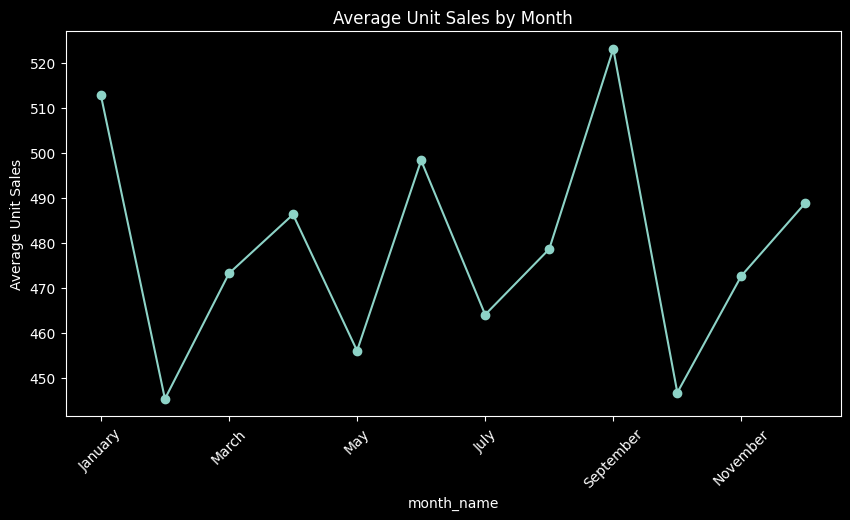

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
monthly_avg.plot(marker='o')
plt.title("Average Unit Sales by Month")
plt.ylabel("Average Unit Sales")
plt.xticks(rotation=45)
plt.show()

- There is no smooth seasonal wave (like gradual rise to December then drop)

In [46]:
df.groupby('month_name')['unit_sales'].std().reindex(month_order)


month_name
January      240.276009
February     158.646195
March        153.824452
April        190.495208
May          145.807429
June         160.790073
July         132.090752
August       132.565374
September    170.744687
October      175.859640
November     183.448637
December     182.305265
Name: unit_sales, dtype: float64

Monthly seasonality exists but is weak compared to weekly seasonality.

## Trend Over Time (Long-Term Movement)

### Smooth the Series (30-Day Rolling Mean)
#### We remove daily fluctuations to see the underlying movement.

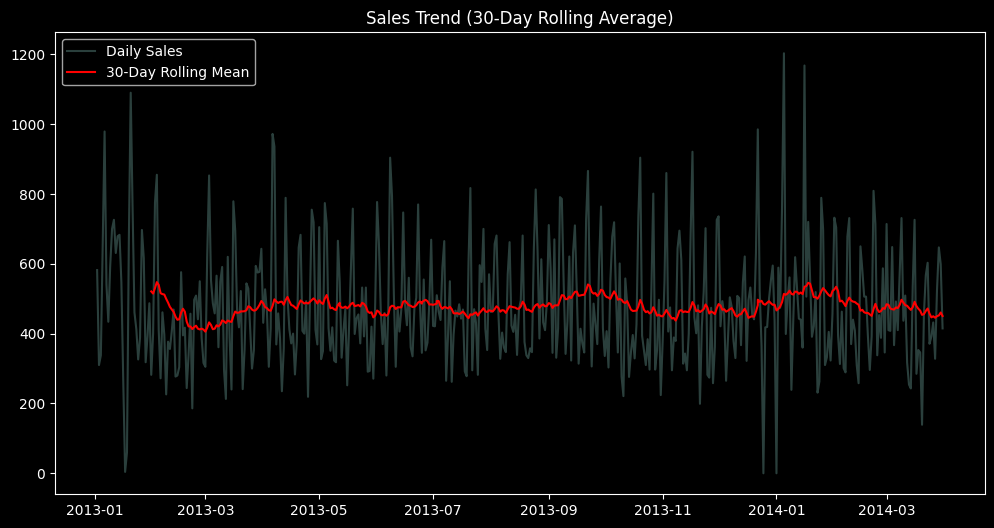

In [47]:
plt.figure(figsize=(12,6))

# Original (light)
plt.plot(df['unit_sales'], alpha=0.3, label='Daily Sales')

# 30-day rolling average
plt.plot(df['unit_sales'].rolling(30).mean(), color='red', label='30-Day Rolling Mean')

plt.title("Sales Trend (30-Day Rolling Average)")
plt.legend()
plt.show()


There is:
- No strong continuous upward trend
- No strong continuous downward trend
- Some medium-term waves
- One noticeable mid-to-late increase
So overall:
The series is relatively stable over time, with mild structural shifts.

Trend is weaker than:
- Weekly seasonality (very strong)
- Holiday effects (clear)
- Trend is moderate.

In [48]:
df['year'] = df.index.year
df.groupby('year')['unit_sales'].mean()


year
2013    478.306233
2014    480.433333
Name: unit_sales, dtype: float64

The series is relatively stationary in level, with strong weekly seasonality and moderate holiday effects, but no meaningful long-term growth pattern.

## Holiday lead/lag effect
#### - Do sales spike before holidays?
#### - Do they drop after holidays?

#### Holiday Indicator (National Only)

In [49]:
# Create national holiday flag
df['is_national_holiday'] = (df['holiday_type'] == 'National').astype(int)

df[['unit_sales', 'is_national_holiday']].head()


,unit_sales,is_national_holiday
date,,
2013-01-02,582.0,0
2013-01-03,310.0,0
2013-01-04,338.0,0
2013-01-05,654.0,1
2013-01-06,979.0,0


#### Lead/Lag Indicators

In [50]:
# 1 day before national holiday
df['before_1'] = df['is_national_holiday'].shift(-1)

# 2 days before national holiday
df['before_2'] = df['is_national_holiday'].shift(-2)

# 1 day after national holiday
df['after_1'] = df['is_national_holiday'].shift(1)

# Replace NaN with 0
df[['before_1', 'before_2', 'after_1']] = df[['before_1', 'before_2', 'after_1']].fillna(0)

df[['unit_sales','is_national_holiday','before_1','before_2','after_1']].head(10)


,unit_sales,is_national_holiday,before_1,before_2,after_1
date,,,,,
2013-01-02,582.0,0,0.0,0.0,0.0
2013-01-03,310.0,0,0.0,1.0,0.0
2013-01-04,338.0,0,1.0,0.0,0.0
2013-01-05,654.0,1,0.0,0.0,0.0
2013-01-06,979.0,0,0.0,0.0,1.0
2013-01-07,541.0,0,0.0,0.0,0.0
2013-01-08,434.0,0,0.0,0.0,0.0
2013-01-09,593.0,0,0.0,0.0,0.0
2013-01-10,700.0,0,0.0,1.0,0.0


Compare average sales for each condition

In [51]:
comparison = {
    "Normal Day": df[df['is_national_holiday'] == 0]['unit_sales'].mean(),
    "Holiday Day": df[df['is_national_holiday'] == 1]['unit_sales'].mean(),
    "1 Day Before": df[df['before_1'] == 1]['unit_sales'].mean(),
    "2 Days Before": df[df['before_2'] == 1]['unit_sales'].mean(),
    "1 Day After": df[df['after_1'] == 1]['unit_sales'].mean()
}

comparison


{'Normal Day': np.float64(477.0045977011494),
 'Holiday Day': np.float64(509.875),
 '1 Day Before': np.float64(451.6666666666667),
 '2 Days Before': np.float64(518.875),
 '1 Day After': np.float64(496.25)}

#### National holidays create a multi-day demand effect. Sales increase significantly on the holiday itself, spike two days before, and remain elevated one day after. This indicates anticipatory and spillover consumer behavior.

## Inspecting the CPI (Consumer Price Index) and the Statutory nominal gross monthly minimum wage (local currency) - Annual

In [52]:
cpi = pd.read_csv("../data/cpi_monthly_2013_2014_to_mar.csv", parse_dates=["date"])
wage = pd.read_csv("../data/min_wage_daily_2013_2014.csv", parse_dates=["date"])

print("CPI:")
print(cpi.head())
print(cpi.info())

print("\nWAGE:")
print(wage.head())
print(wage.info())

CPI:
        date         cpi
0 2013-02-01  142.606066
1 2013-03-01  143.231229
2 2013-04-01  143.487622
3 2013-05-01  143.174965
4 2013-06-01  142.967662
<class 'pandas.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    14 non-null     datetime64[us]
 1   cpi     14 non-null     float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 356.0 bytes
None

WAGE:
        date  min_wage
0 2013-01-01       318
1 2013-01-02       318
2 2013-01-03       318
3 2013-01-04       318
4 2013-01-05       318
<class 'pandas.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   date      366 non-null    datetime64[us]
 1   min_wage  366 non-null    int64         
dtypes: datetime64[us](1), int64(1)
memory usage: 5.8 KB
None


In [53]:
print("\nWAGE:")
print(wage.head())
print(wage.info())


WAGE:
        date  min_wage
0 2013-01-01       318
1 2013-01-02       318
2 2013-01-03       318
3 2013-01-04       318
4 2013-01-05       318
<class 'pandas.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   date      366 non-null    datetime64[us]
 1   min_wage  366 non-null    int64         
dtypes: datetime64[us](1), int64(1)
memory usage: 5.8 KB
None


### The wage dataset is artificially daily.
Minimum wage does NOT change daily — it’s constant over long periods.

Between 2013 and March 2014, CPI moves slightly month to month. Minimum wage probably changes once.
The sales show strong weekly variation
Therefore, macro variables will only explain:
* Long-term purchasing power
* Structural shifts
NOT
Daily seasonality

In [54]:
## confirm wage changes
wage['min_wage'].unique()

array([318, 340])

#### 2013 → 318
#### 2014 → 340 (most likely starting Jan 1, 2014)
This is structurally correct macro behavior.

Between 2013 and March 2014:
* CPI change = gradual
* Wage change = one discrete jump
* Sales = high-frequency daily with strong weekly seasonality

So macro variables will behave like:
* Low-frequency structural drivers
* NOT short-term predictors
* This is perfectly aligned with economic theory.

### Frequency Alignment Strategy

In [55]:
cpi = cpi.set_index("date").sort_index()
wage = wage.set_index("date").sort_index()

print(cpi.index.min(), cpi.index.max())
print(wage.index.min(), wage.index.max())

2013-02-01 00:00:00 2014-03-01 00:00:00
2013-01-01 00:00:00 2014-01-01 00:00:00


In [56]:
## Expand CPI to Daily
cpi_daily = cpi.asfreq("D").ffill() ## CPI value from Feb 1 stays constant until next month

In [57]:
## Align CPI to Sales Date Range
cpi_daily = cpi_daily.reindex(df.index).ffill()

In [58]:
## Check Missing Values
cpi_daily.isna().sum()

cpi    30
dtype: int64

#### 30 daily observations still have missing CPI - Most probably for January 2013 since the month is missing, CPI starts 2013-02-01

In [59]:
## Backfill January CPI
cpi_daily = cpi_daily.bfill()
cpi_daily.isna().sum()

cpi    0
dtype: int64

#### Merge CPI & Wage into Sales Dataset

In [60]:
## Merge CPI
df = df.merge(
    cpi_daily[['cpi']],
    how='left',
    left_index=True,
    right_index=True
)

In [61]:
## Merge Wage
df = df.merge(
    wage[['min_wage']],
    how='left',
    left_index=True,
    right_index=True
)

In [62]:
df[['unit_sales', 'cpi', 'min_wage']].head()
df[['cpi', 'min_wage']].isna().sum()

cpi          0
min_wage    89
dtype: int64

#### Wage ends at 2014-01-01 and sales go until March 2014. Minimum wage in Ecuador in 2014 did NOT change again after Jan 1, so safely forward fill

In [63]:
## Forward fill
df['min_wage'] = df['min_wage'].ffill()
df[['cpi','min_wage']].isna().sum()

cpi         0
min_wage    0
dtype: int64

### Payday Effect

In [64]:
df['day_of_month'] = df.index.day

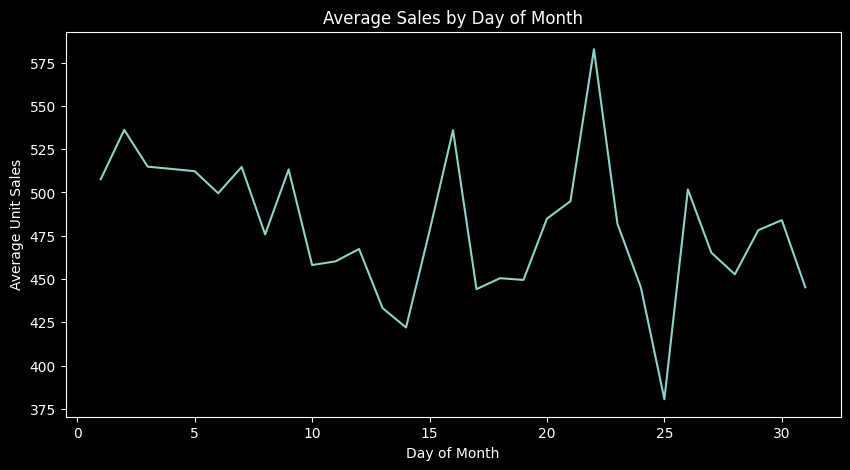

In [65]:
import matplotlib.pyplot as plt

avg_by_dom = df.groupby('day_of_month')['unit_sales'].mean()
plt.figure(figsize=(10,5))
avg_by_dom.plot()
plt.title("Average Sales by Day of Month")
plt.xlabel("Day of Month")
plt.ylabel("Average Unit Sales")
plt.show()

real monthly effect or just weekly overlap?

In [66]:
# 1) check duplicate dates
print("Index duplicates?", df.index.has_duplicates)
print("Number of duplicate dates:", df.index.duplicated().sum())

# 2) show a few duplicate dates (if any)
dup_dates = df.index[df.index.duplicated()].unique()
print("Example duplicate dates:", dup_dates[:10])

# 3) check duplicate column names (after merges)
dup_cols = df.columns[df.columns.duplicated()].tolist()
print("Duplicate columns:", dup_cols)

Index duplicates? True
Number of duplicate dates: 17
Example duplicate dates: DatetimeIndex(['2013-05-12', '2013-06-25', '2013-07-03', '2013-12-22'], dtype='datetime64[us]', name='date', freq=None)
Duplicate columns: []


In [67]:
df = df[~df.index.duplicated(keep="first")].sort_index()

In [68]:
pd.crosstab(df['day_of_month'], df['day_of_week'])

day_of_week,Friday,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday
day_of_month,,,,,,,
1,3,2,3,2,1,1,2
2,1,2,3,3,2,2,2
3,2,3,1,3,2,2,2
4,2,3,2,1,2,3,2
5,2,1,2,2,2,3,3
6,2,2,2,2,3,1,3
7,3,2,2,2,3,2,1
8,3,2,3,2,1,2,2
9,1,2,3,3,2,2,2


* the spike at Day 16 is almost entirely explained by weekly seasonality, not a monthly payday effect
* Day 22 spike” is simply a concentration of high-demand weekdays
#### There is no convincing payday effect in this dataset.

### Weather Effect

In [69]:
## Load NASA POWER CSV
import pandas as pd
import numpy as np

path = "../data/quito_power_daily_2013_2014.csv"  # change to your filename

# 1) Find the line number of "-END HEADER-"
with open(path, "r", encoding="utf-8") as f:
    lines = f.readlines()

end_header_idx = [i for i, line in enumerate(lines) if "-END HEADER-" in line][0]

# 2) Read the CSV starting from the next line (the real column header)
power = pd.read_csv(path, skiprows=end_header_idx + 1)

# 3) Replace -999 with NaN
power = power.replace(-999, np.nan)

# 4) Build date from YEAR + DOY
power['date'] = pd.to_datetime(power['YEAR'].astype(str), format="%Y") + pd.to_timedelta(power['DOY'] - 1, unit='D')
power = power.set_index('date').sort_index()

power.head()

,YEAR,DOY,ALLSKY_SFC_SW_DWN,PRECTOTCORR,T2M,T2M_MAX,T2M_MIN
date,,,,,,,
2013-01-01,2013,1,9.75,2.48,17.24,23.21,12.79
2013-01-02,2013,2,11.06,1.39,16.96,22.68,12.76
2013-01-03,2013,3,10.07,5.78,17.28,22.80,13.33
2013-01-04,2013,4,12.94,3.32,17.31,22.00,13.09
2013-01-05,2013,5,12.09,5.53,17.78,24.14,12.52


In [70]:
## merge and create sunny/rainy features
df = df.merge(
    power[['ALLSKY_SFC_SW_DWN','PRECTOTCORR','T2M','T2M_MAX','T2M_MIN']],
    how='left',
    left_index=True,
    right_index=True
)

df['is_sunny'] = (df['ALLSKY_SFC_SW_DWN'] >= df['ALLSKY_SFC_SW_DWN'].quantile(0.7)).astype(int)
df['is_rainy'] = (df['PRECTOTCORR'] > 5).astype(int)

df.groupby('is_sunny')['unit_sales'].mean(), df.groupby('is_rainy')['unit_sales'].mean()

(is_sunny
 0    469.182390
 1    498.536765
 Name: unit_sales, dtype: float64,
 is_rainy
 0    477.537572
 1    479.379630
 Name: unit_sales, dtype: float64)

#### Sunny days are associated with an average increase of approximately 29 units in sales.
#### In contrast, rainy days show only a marginal difference (~2 units), suggesting precipitation has limited impact on consumer purchasing behavior in Quito.

In [71]:
df.groupby(['is_sunny','is_rainy'])['unit_sales'].mean()

is_sunny  is_rainy
0         0           466.092105
          1           477.011111
1         0           499.652542
          1           491.222222
Name: unit_sales, dtype: float64

* Sunshine clearly increases sales.

Rain:
* Increases sales slightly when not sunny (+11)
* Slightly dampens sunny effect (499 → 491)
* But rain effect is much weaker than sunshine effect.

Sales are highest on sunny days without rain (~500 units).
Rain slightly reduces the positive effect of sunshine, but precipitation alone has limited impact.
This suggests that solar radiation is the primary weather-related driver of consumer demand in Quito.

#### Weather Interaction Analysis

In [72]:
df['solar_7d'] = df['ALLSKY_SFC_SW_DWN'].rolling(7).mean()
df['solar_7d']

date
2013-01-02          NaN
2013-01-03          NaN
2013-01-04          NaN
2013-01-05          NaN
2013-01-06          NaN
                ...    
2014-03-27    11.917143
2014-03-28    13.182857
2014-03-29    13.292857
2014-03-30    13.522857
2014-03-31    14.690000
Name: solar_7d, Length: 454, dtype: float64

In [73]:
df['solar_7d'].isna().sum()

np.int64(6)

In [74]:
## Impute nans with mean
df['solar_7d'] = df['ALLSKY_SFC_SW_DWN'].rolling(7, min_periods=1).mean()
df = df.dropna(subset=['solar_7d'])

In [75]:
both_count = df[(df['is_sunny'] == 1) & (df['is_rainy'] == 1)].shape[0]
both_pct = both_count / len(df) * 100

sunny_only = df[(df['is_sunny'] == 1) & (df['is_rainy'] == 0)].shape[0] / len(df) * 100
rainy_only = df[(df['is_sunny'] == 0) & (df['is_rainy'] == 1)].shape[0] / len(df) * 100

print(f"Sunny & Rainy: {both_pct:.2f}%")
print(f"Sunny only: {sunny_only:.2f}%")
print(f"Rainy only: {rainy_only:.2f}%")

Sunny & Rainy: 3.96%
Sunny only: 25.99%
Rainy only: 19.82%


In [76]:
## check overall missing
df[['ALLSKY_SFC_SW_DWN','PRECTOTCORR','solar_7d']].isna().sum()

ALLSKY_SFC_SW_DWN    0
PRECTOTCORR          0
solar_7d             0
dtype: int64

### Correlation Overview

In [77]:
exog_cols = [
    'ALLSKY_SFC_SW_DWN',
    'solar_7d',
    'PRECTOTCORR',
    'dcoilwtico'
]

df[['unit_sales'] + exog_cols].corr()

,unit_sales,ALLSKY_SFC_SW_DWN,solar_7d,PRECTOTCORR,dcoilwtico
unit_sales,1.000000,0.101362,0.076699,0.004066,0.003497
ALLSKY_SFC_SW_DWN,0.101362,1.000000,0.564482,-0.217770,0.061189
solar_7d,0.076699,0.564482,1.000000,-0.225623,0.135478
PRECTOTCORR,0.004066,-0.217770,-0.225623,1.000000,-0.312606
dcoilwtico,0.003497,0.061189,0.135478,-0.312606,1.000000


Weather–Sales Relationship

Solar radiation shows a small positive linear correlation with sales (ρ ≈ 0.10).

Precipitation and oil prices show near-zero linear correlation.

The 7-day rolling solar variable is moderately correlated with raw solar (ρ ≈ 0.56), indicating potential multicollinearity if both are included.

Despite the weak linear correlation, the binary sunny indicator shows an average increase of approximately 29 units in sales. This suggests that the weather effect may be nonlinear, and that a threshold-based feature (sunny vs. not sunny) may capture behavioral effects more effectively than continuous solar radiation.

#### Save cleaned dataset

In [78]:
# 1) make sure date is a column for CSV export
out = df.copy()
out = out.reset_index()  # only if date is index

# 2) convert booleans to ints (SARIMAX/ML friendly)
for col in ['is_holiday', 'is_sunny', 'is_rainy']:
    if col in out.columns:
        out[col] = out[col].astype(int)

# 3) remove helper columns you don't want (optional)
# out = out.drop(columns=['YEAR','DOY'], errors='ignore')

# 4) final sanity check: no NaNs in model columns
model_cols = ['unit_sales', 'is_holiday', 'is_sunny', 'dcoilwtico', 'cpi', 'min_wage', 'ALLSKY_SFC_SW_DWN']
existing = [c for c in model_cols if c in out.columns]
print(out[existing].isna().sum())

# 5) save
out.to_csv("../data/cleaned_timeseries.csv", index=False)

unit_sales           0
is_holiday           0
is_sunny             0
dcoilwtico           0
cpi                  0
min_wage             0
ALLSKY_SFC_SW_DWN    0
dtype: int64
